# Hidden Markov Models

### Imports

In [39]:
import numpy as np
from scipy.special import logsumexp
from hmm import Mess3Proc, HMM
import torch as t
from tqdm import tqdm
from model import HookedTransformerModel
import os

### True Log Probabilities

In [64]:
# Generate test sequences from Mess3Proc
mess3_proc = Mess3Proc()
seq_length = 3
batch_size = 100

# Generate sequences (batch_size, seq_length)
test_sequences = mess3_proc.generate_data(batch_size=batch_size, length=seq_length, use_tqdm=False)

test_sequences = t.tensor([[0, 0, 0, 0, 0, 0]])
print(f"Generated sequences shape: {test_sequences.shape}")

Generated sequences shape: torch.Size([1, 6])


In [90]:
def compute_log_likelihood_forward_conditional(hmm: HMM, observations: np.ndarray, offset: int = 0, reduction: str | None = None) -> np.ndarray:
    """
    Compute log P(x_offset+1, ..., x_T | x_0, ..., x_offset) using forward algorithm.
    
    This matches transformer which can't predict first token.
    
    Args:
        hmm: HMM instance
        observations: (batch_size, seq_length) where observations[:,0] is conditioning variable
    
    Returns:
        log_likelihoods: (batch_size,) log P(x_0,...,x_T) and (batch_size,) log P(x_0,...,x_offset)
    
    Some pending optimization on code logic... but passed all tests.
    """
    batch_size, seq_length = observations.shape
    n_states = hmm.num_hidden_states
    emission_matrices = hmm.emission_matrices
    log_emission_matrices = np.log(emission_matrices)
    
    # Get stationary distribution for initialization
    init_state = hmm.get_stationary_distribution()
    log_init_state = np.log(init_state)
    
    log_likelihoods = []
    baseline_log_likelihoods = []
    for batch_idx in tqdm(range(batch_size), desc="Computing conditional log-likelihoods"):
        obs_seq = observations[batch_idx]
        
        # Initialize with x₀: compute belief state after observing x₀
        # belief(s') = Σ_s π(s) × T[x₀, s, s']
        log_emission_0 = log_emission_matrices[obs_seq[0]]  # (n_states, n_states)
        log_alpha = logsumexp(log_init_state[:, np.newaxis] + log_emission_0, axis=0)
        
        # Now compute P(x₁, ..., x_{T-1} | belief after x₀)
        # This is the conditional likelihood given x₀
        log_conditional_likelihood = 0.0
        if offset == 0:
            baseline_log_likelihood = logsumexp(log_alpha)
        elif offset >= seq_length:
            raise ValueError(f"Offset {offset} is too large for sequence length {seq_length}")
        elif offset == -1:
            baseline_log_likelihood = logsumexp(log_init_state)
        for t in range(1, seq_length):
            log_emission_t = log_emission_matrices[obs_seq[t]]
            
            # Compute P(x_t | previous belief)
            # = Σ_s belief(s) × Σ_s' T[x_t, s, s']
            log_prob_xt = logsumexp(log_alpha[:, np.newaxis] + log_emission_t)
            log_conditional_likelihood += log_prob_xt
            
            # Update belief: α_new(s') = Σ_s α(s) × T[x_t, s, s']
            log_alpha = logsumexp(log_alpha[:, np.newaxis] + log_emission_t, axis=0)
            if t == offset:
                baseline_log_likelihood = logsumexp(log_alpha)
        
        # print(log_conditional_likelihood)
        # print(logsumexp(log_alpha))
        baseline_log_likelihoods.append(logsumexp(baseline_log_likelihood))
        log_likelihoods.append(logsumexp(log_alpha))
    
    cond_log_likelihoods = np.array(log_likelihoods) - np.array(baseline_log_likelihoods)
    if reduction == 'mean':
        return cond_log_likelihoods.mean()
    elif reduction == 'sum':
        return cond_log_likelihoods.sum()
    elif reduction is None:
        return cond_log_likelihoods
    else:
        print(f"Invalid reduction: {reduction}, returning all values")
        return cond_log_likelihoods

### KL Divergence Estimation

In [61]:
model = HookedTransformerModel(cfg_paths[4])
model.load_state_dict(t.load(mdl_paths[4], map_location='cpu'))
model.eval()

HookedTransformerModel(
  (model): HookedTransformer(
    (embed): Embed()
    (hook_embed): HookPoint()
    (pos_embed): PosEmbed()
    (hook_pos_embed): HookPoint()
    (blocks): ModuleList(
      (0-1): 2 x TransformerBlock(
        (ln1): Identity()
        (attn): Attention(
          (hook_k): HookPoint()
          (hook_q): HookPoint()
          (hook_v): HookPoint()
          (hook_z): HookPoint()
          (hook_attn_scores): HookPoint()
          (hook_pattern): HookPoint()
          (hook_result): HookPoint()
        )
        (hook_attn_in): HookPoint()
        (hook_q_input): HookPoint()
        (hook_k_input): HookPoint()
        (hook_v_input): HookPoint()
        (hook_mlp_in): HookPoint()
        (hook_attn_out): HookPoint()
        (hook_mlp_out): HookPoint()
        (hook_resid_pre): HookPoint()
        (hook_resid_post): HookPoint()
      )
    )
    (unembed): Unembed()
  )
)

In [95]:
@t.no_grad()
def compute_transformer_log_likelihood(model: HookedTransformerModel, sequences: t.Tensor, reduction: str | None = None) -> np.ndarray:
    """
    Compute log P(x_n_ctx, ..., x_T | x_0, ..., x_{n_ctx-1}) from transformer next-token predictions.
    Uses GPU-accelerated batching for efficiency.
    """
    batch_size, seq_length = sequences.shape
    n_ctx = model.model.cfg.n_ctx
    
    # Create all chopped sequences for all batches at once
    # For each sequence, create chunks [i:i+n_ctx] for i in range(seq_length - n_ctx)
    indices = range(seq_length - n_ctx)
    chopped_seqs = t.stack([sequences[:, i:i+n_ctx] for i in indices], dim=1)
    # Shape: (batch_size, seq_length - n_ctx, n_ctx)
    
    # Flatten batch dimensions for model input
    flat_input = chopped_seqs.reshape(-1, n_ctx)
    # Shape: (batch_size * (seq_length - n_ctx), n_ctx)
    
    # Process all at once
    logits = model(flat_input)
    # Shape: (batch_size * (seq_length - n_ctx), n_ctx, vocab_size)
    
    # Reshape back to separate batch dimension
    logits = logits.reshape(batch_size, seq_length - n_ctx, n_ctx, -1)
    # Take last position predictions
    log_probs = t.log_softmax(logits[:, :, -1, :], dim=-1)
    # Shape: (batch_size, seq_length - n_ctx, vocab_size)
    
    # Gather correct tokens
    correct_tokens = sequences[:, n_ctx:]  # (batch_size, seq_length - n_ctx)
    log_probs_selected = t.gather(log_probs, dim=-1, index=correct_tokens.unsqueeze(-1)).squeeze(-1)
    # Shape: (batch_size, seq_length - n_ctx)
    
    # Sum over sequence length to get per-sequence log-likelihoods
    seq_log_likelihoods = log_probs_selected.sum(dim=1)
    # Shape: (batch_size,)
    
    if reduction == 'mean':
        return seq_log_likelihoods.mean().cpu().numpy()
    elif reduction == 'sum':
        return seq_log_likelihoods.sum().cpu().numpy()
    elif reduction is None:
        return seq_log_likelihoods.cpu().numpy()
    else:
        print(f"Invalid reduction: {reduction}, returning all values")
        return seq_log_likelihoods.cpu().numpy()


In [96]:
proc = Mess3Proc()
test_sequences = proc.generate_data(batch_size=100, length=100, use_tqdm=False)

In [98]:
# Compute ground truth log-likelihoods (conditional on first token, matching transformer)
# test_sequences = t.tensor([[0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 0, 1]])
test_sequences_np = test_sequences.numpy()
cond_log_likelihoods = compute_log_likelihood_forward_conditional(mess3_proc, test_sequences_np, offset=3)
# print(f"True log-likelihoods shape: {true_log_likelihoods.shape}")
# print(f"Mean log-likelihood: {true_log_likelihoods.mean():.4f}")
# print(f"Std log-likelihood: {true_log_likelihoods.std():.4f}")

# print(f"Baseline log-likelihoods shape: {baseline_log_likelihoods.shape}")
# print(f"Mean baseline log-likelihood: {baseline_log_likelihoods.mean():.4f}")
# print(f"Std baseline log-likelihood: {baseline_log_likelihoods.std():.4f}")


# print(f"Cond log likelihoods shape: {cond_log_likelihoods.shape}")
print(f"Mean cond log likelihood: {cond_log_likelihoods.mean():.4f}")
print(f"Std cond log likelihood: {cond_log_likelihoods.std():.4f}")

learned_log_likelihoods = compute_transformer_log_likelihood(model, test_sequences)

# print(f"Learned log-likelihoods shape: {learned_log_likelihoods.shape}")
print(f"Mean learned log-likelihood: {learned_log_likelihoods.mean():.4f}")
print(f"Std learned log-likelihood: {learned_log_likelihoods.std():.4f}")


Computing conditional log-likelihoods: 100%|██████████| 100/100 [00:01<00:00, 83.39it/s]


Mean cond log likelihood: -74.2771
Std cond log likelihood: 8.1707
Mean learned log-likelihood: -75.7717
Std learned log-likelihood: 7.5258


### Putting together tests

In [45]:
def compute_transformer_log_likelihood(model: HookedTransformerModel,
                                       sequences: t.Tensor) -> np.ndarray:
    """
    Compute log P(x₁, ..., x_T | x₀) from transformer next-token predictions.

    Args:
        model: Trained HookedTransformerModel
        sequences: (batch_size, seq_length) token sequences

    Returns:
        log_likelihoods: (batch_size,) log probability of each sequence (excluding first token)
    """
    model.eval()
    batch_size, seq_length = sequences.shape
    ctx_len = model.model.cfg.n_ctx

    seq_log_likelihoods = []

    with t.no_grad():
        for b in range(batch_size):
            seq = sequences[b]  # (seq_length,)
            seq_log_prob = 0.0

            # For each position starting from 1 (skip first token)
            for pos in range(seq_length):
                # Determine context window: [max(0, pos - ctx_len + 1), pos+1)
                start_idx = max(0, pos - ctx_len + 1)
                context = seq[start_idx:pos + 1]  # (context_len,)

                # Pad if context is shorter than ctx_len
                if len(context) < ctx_len:
                    padding = t.zeros(ctx_len - len(context), dtype=context.dtype, device=context.device)
                    context = t.cat([padding, context])

                # Get model prediction for the context
                context_input = context.unsqueeze(0)  # (1, ctx_len)
                logits = model(context_input)  # (1, ctx_len, vocab_size)

                # Get log probability for the last position (predicting current token)
                log_probs = t.log_softmax(logits[0, -1, :], dim=-1)  # (vocab_size,)

                # Add log probability of the actual token at position pos
                seq_log_prob += log_probs[seq[pos]].item()

            seq_log_likelihoods.append(seq_log_prob)

    return np.array(seq_log_likelihoods)


# Load all models and compute learned log-likelihoods
model_results = {}

for ctx_len, model_dir in mess3_weight_paths.items():
    print(f"\nProcessing context length {ctx_len}...")
    
    # Load model
    cfg_path = cfg_paths[ctx_len]
    mdl_path = mdl_paths[ctx_len]
    
    model = HookedTransformerModel(cfg_path)
    model.load_state_dict(t.load(mdl_path, map_location='cpu'))
    model.eval()
    
    # Compute log-likelihoods
    learned_log_likelihoods = compute_transformer_log_likelihood(model, test_sequences)
    
    model_results[ctx_len] = {
        'learned_log_liks': learned_log_likelihoods,
        'model': model
    }
    
    print(f"Mean learned log-likelihood: {learned_log_likelihoods.mean():.4f}")
    print(f"Std learned log-likelihood: {learned_log_likelihoods.std():.4f}")


Processing context length 4...


ValueError: too many values to unpack (expected 2)

Context length 4:
  KL(True || Learned) = -13.645378 ± 0.000000 nats
  KL in bits: -19.686120 ± 0.000000
Context length 6:
  KL(True || Learned) = -13.431495 ± 0.000000 nats
  KL in bits: -19.377551 ± 0.000000
Context length 8:
  KL(True || Learned) = -13.309929 ± 0.000000 nats
  KL in bits: -19.202169 ± 0.000000
Context length 10:
  KL(True || Learned) = -13.148526 ± 0.000000 nats
  KL in bits: -18.969313 ± 0.000000
Context length 15:
  KL(True || Learned) = -14.617911 ± 0.000000 nats
  KL in bits: -21.089188 ± 0.000000


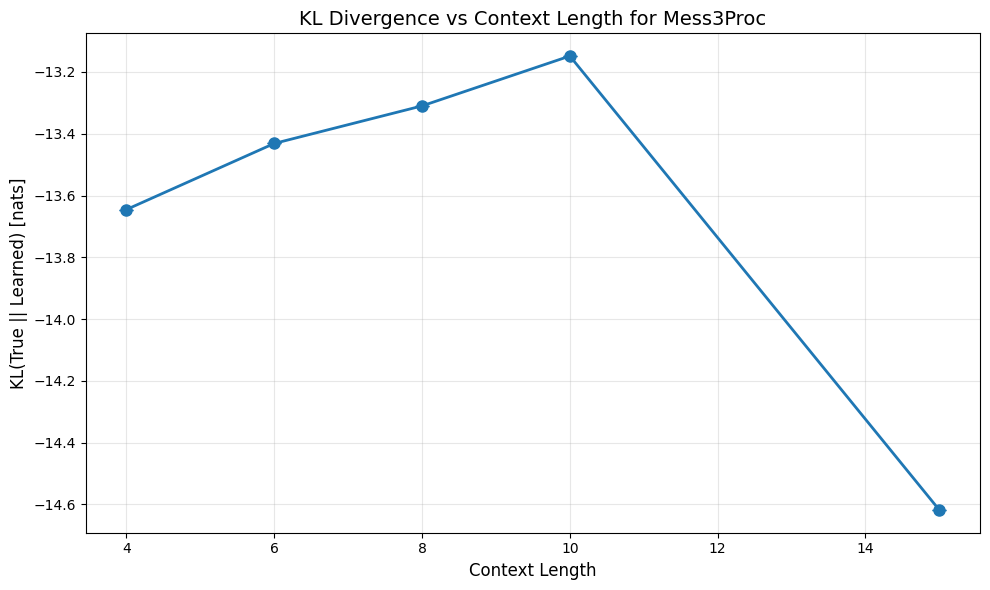


=== Summary ===
Best model (lowest KL): Context length 15
Worst model (highest KL): Context length 10

KL values in bits:
  Context 4: -19.6861 ± 0.0000 bits
  Context 6: -19.3776 ± 0.0000 bits
  Context 8: -19.2022 ± 0.0000 bits
  Context 10: -18.9693 ± 0.0000 bits
  Context 15: -21.0892 ± 0.0000 bits


In [35]:
# Compute KL divergence: KL(P_true || P_learned) = E_x~P_true[log P_true(x) - log P_learned(x)]

kl_divergences = {}

for ctx_len in mess3_weight_paths.keys():
    learned_log_liks = model_results[ctx_len]['learned_log_liks']
    
    # Monte Carlo estimate: (1/N) * sum_i [log P_true(x_i) - log P_learned(x_i)]
    kl_estimate = np.mean(true_log_likelihoods - learned_log_liks)
    
    # Standard error for MC estimate
    differences = true_log_likelihoods - learned_log_liks
    kl_std_error = np.std(differences) / np.sqrt(len(differences))
    
    kl_divergences[ctx_len] = {
        'kl': kl_estimate,
        'std_error': kl_std_error
    }
    
    print(f"Context length {ctx_len}:")
    print(f"  KL(True || Learned) = {kl_estimate:.6f} ± {kl_std_error:.6f} nats")
    print(f"  KL in bits: {kl_estimate / np.log(2):.6f} ± {kl_std_error / np.log(2):.6f}")


# Visualization
import matplotlib.pyplot as plt

ctx_lengths = sorted(kl_divergences.keys())
kl_values = [kl_divergences[k]['kl'] for k in ctx_lengths]
kl_errors = [kl_divergences[k]['std_error'] for k in ctx_lengths]

plt.figure(figsize=(10, 6))
plt.errorbar(ctx_lengths, kl_values, yerr=kl_errors, marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Context Length', fontsize=12)
plt.ylabel('KL(True || Learned) [nats]', fontsize=12)
plt.title('KL Divergence vs Context Length for Mess3Proc', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Summary ===")
print(f"Best model (lowest KL): Context length {ctx_lengths[np.argmin(kl_values)]}")
print(f"Worst model (highest KL): Context length {ctx_lengths[np.argmax(kl_values)]}")
print(f"\nKL values in bits:")
for ctx_len in ctx_lengths:
    kl_bits = kl_divergences[ctx_len]['kl'] / np.log(2)
    kl_bits_err = kl_divergences[ctx_len]['std_error'] / np.log(2)
    print(f"  Context {ctx_len}: {kl_bits:.4f} ± {kl_bits_err:.4f} bits")

In [44]:
# Models with different context lengths
mess3_weight_paths = {
    4: 'records/20251127_122141',
    6: 'records/20251127_135107',
    8: 'records/20251127_135742',
    10: 'records/20251127_134441',
    15: 'records/20251127_135035',
}
cfg_paths = {key: os.path.join(value, 'config.yaml') for key, value in mess3_weight_paths.items()}
mdl_paths = {key: os.path.join(value, 'final_model_mess3.pt') for key, value in mess3_weight_paths.items()}
model = HookedTransformerModel(cfg_paths[4])
model.load_state_dict(t.load(mdl_paths[4], map_location='cpu'))
model.eval()

test_sequences = t.randint(0, 3, (3, 4, 4, 3))
model.model(test_sequences)

RuntimeError: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 2

## Generality of Fractal Structures in Belief States